Starting Q-learning training for 3000 episodes...


  7%|▋         | 216/3000 [00:01<00:20, 132.85it/s]

Coverage sweep at episode 200 ...


 14%|█▍        | 426/3000 [00:02<00:18, 142.60it/s]

Coverage sweep at episode 400 ...


...

Coverage sweep at episode 2600 ...


 94%|█████████▍| 2826/3000 [00:18<00:01, 145.56it/s]

Coverage sweep at episode 2800 ...


100%|██████████| 3000/3000 [00:20<00:00, 148.39it/s]


Training completed!


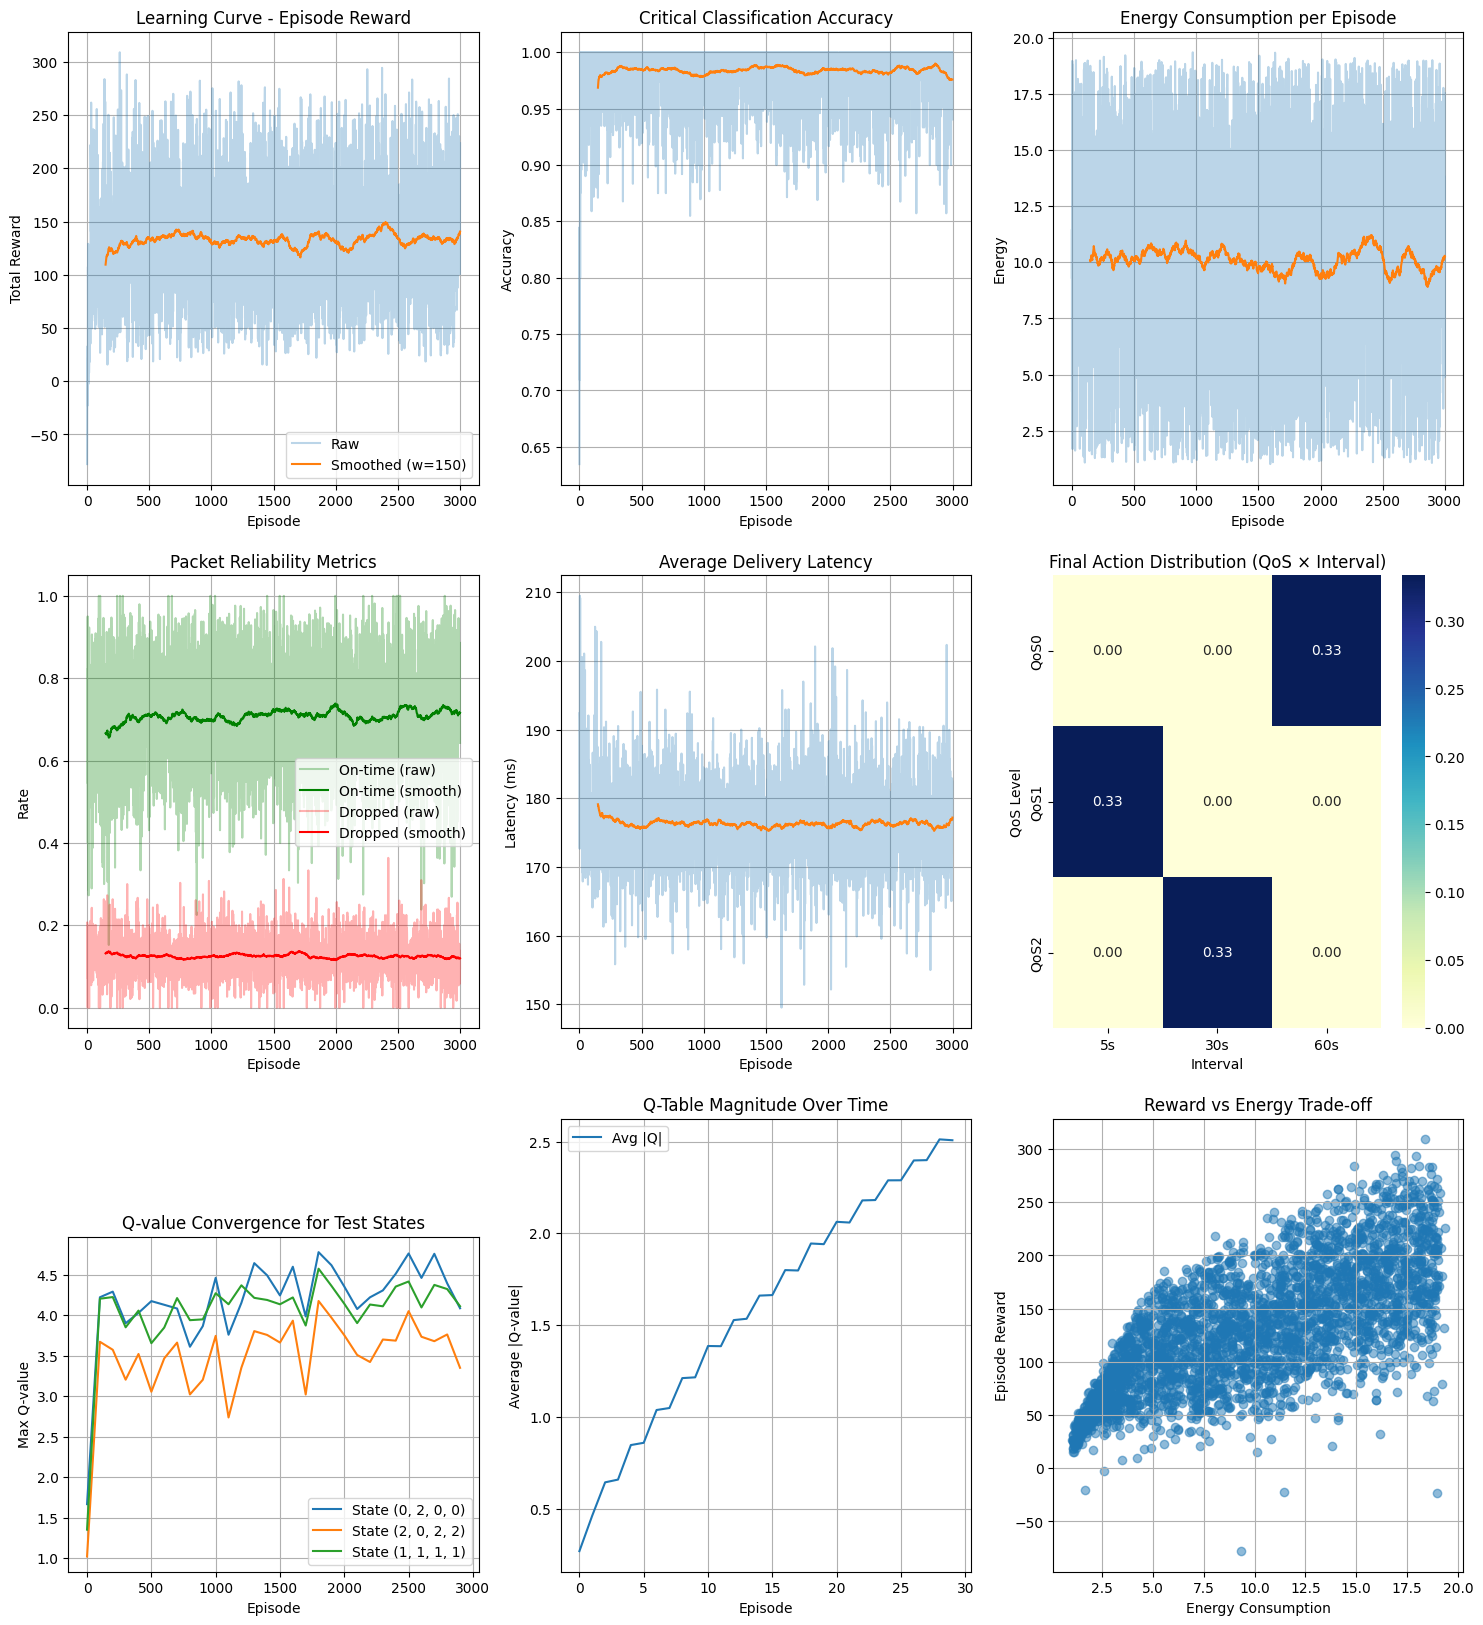


Policy Analysis with Expected Ideal Actions:

State (Δ0, B=2, L=0, D=0):
  Best action: QoS=0, Interval=60s, Critical=0
  Q-value: 4.72
  Ideal QoS: 0, Ideal Interval: 5s
  Critical match: ✓
  Top 1: QoS=0✓, τ=60s✗, c=0 (Q=4.72)
  Top 2: QoS=1✗, τ=60s✗, c=0 (Q=2.99)
  Top 3: QoS=1✗, τ=60s✗, c=1 (Q=2.96)

State (Δ2, B=0, L=2, D=2):
  Best action: QoS=1, Interval=5s, Critical=1
  Q-value: 4.08
  Ideal QoS: 2, Ideal Interval: 5s
  Critical match: ✓
  Top 1: QoS=1✗, τ=5s✓, c=1 (Q=4.08)
  Top 2: QoS=2✓, τ=60s✗, c=1 (Q=3.17)
  Top 3: QoS=2✓, τ=30s✗, c=1 (Q=3.14)

State (Δ1, B=1, L=1, D=1):
  Best action: QoS=2, Interval=30s, Critical=1
  Q-value: 4.32
  Ideal QoS: 1, Ideal Interval: 5s
  Critical match: ✓
  Top 1: QoS=2✗, τ=30s✗, c=1 (Q=4.32)
  Top 2: QoS=1✓, τ=5s✓, c=1 (Q=3.61)
  Top 3: QoS=0✗, τ=60s✗, c=0 (Q=3.57)

State-Action Pair Coverage Summary:
  State-action pairs encountered: 1458 / 1458 (100.00%)
  Well-visited pairs (≥10 visits): 1458 / 1458
  Unique states visited: 81 / 81 (100

In [ ]:
# take it as baseline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tqdm import tqdm


class RealisticEnvSimulator:
    def __init__(self):
        self.battery = 1.0
        self.window_size = 20
        self.delay_window = []
        self.loss_window = []
        self.delta_ema = None
        self.delta_alpha = 0.1
        self.delta_std = 1.0

    def update_ema(self, x):
        if self.delta_ema is None:
            self.delta_ema = x
        else:
            self.delta_ema = self.delta_alpha * x + \
                (1 - self.delta_alpha) * self.delta_ema
        return self.delta_ema

    def compute_delta(self, x):
        ema = self.update_ema(x)
        delta = abs(x - ema) / (self.delta_std + 1e-8)
        return delta

    def compute_loss_rate(self):
        if len(self.loss_window) < self.window_size:
            return 0.0
        return 1.0 - np.mean(self.loss_window[-self.window_size:])

    def compute_avg_delay(self):
        if len(self.delay_window) == 0:
            return 0
        return np.mean(self.delay_window[-self.window_size:])

    def discretize_state(self, delta, battery, loss, delay):
        """Convert continuous observations to discrete levels"""
        # Delta level
        if delta < 1:
            delta_lvl = 0   # Small
        elif delta < 3:
            delta_lvl = 1  # Medium
        else:
            delta_lvl = 2   # Large

        # Battery level
        if battery < 0.3:
            battery_lvl = 0   # Low
        elif battery < 0.7:
            battery_lvl = 1  # Medium
        else:
            battery_lvl = 2   # High

        # Loss level
        if loss < 0.1:
            loss_lvl = 0    # Low
        elif loss < 0.3:
            loss_lvl = 1  # Medium
        else:
            loss_lvl = 2    # High

        # Delay level
        if delay < 100:
            delay_lvl = 0    # Low
        elif delay < 500:
            delay_lvl = 1  # Medium
        else:
            delay_lvl = 2    # High

        return delta_lvl, battery_lvl, loss_lvl, delay_lvl

    def simulate_environment(self, state, action):
        delta_lvl, battery_lvl, loss_lvl, delay_lvl = state
        qos, interval, critical = action

        # --- Generate raw input values ---
        sensor_value = np.random.uniform(10, 30)  # fake temp
        delta = self.compute_delta(sensor_value)

        # --- Energy usage ---
        qos_energy = 0.05 * qos
        interval_energy = 2.0 / interval
        energy_cost = qos_energy + interval_energy
        self.battery = max(0.0, self.battery - energy_cost * 0.05)

        # --- Delay simulation ---
        base_delay = np.random.normal(100 + 50 * (2 - qos), 20)
        delay = np.clip(base_delay + 1000 / interval, 0, 800)
        self.delay_window.append(delay)

        # --- Packet loss simulation ---
        loss_chance = 0.1 * (2 - qos) + 0.01 * delay / \
            100  # more delay = more loss
        is_delivered = np.random.rand() > loss_chance
        self.loss_window.append(int(is_delivered))

        # --- Status & latency ---
        packet_status = 'dropped'
        if is_delivered:
            packet_status = 'on_time' if delay < 300 else 'late'
        latency = delay if is_delivered else 1000

        # --- Discretization for next state ---
        next_delta_lvl = 0 if delta < 1 else (1 if delta < 3 else 2)
        next_battery_lvl = 0 if self.battery < 0.3 else (
            1 if self.battery < 0.7 else 2)
        loss_rate = self.compute_loss_rate()
        next_loss_lvl = 0 if loss_rate < 0.1 else (1 if loss_rate < 0.3 else 2)
        avg_delay = self.compute_avg_delay()
        next_delay_lvl = 0 if avg_delay < 100 else (
            1 if avg_delay < 500 else 2)

        new_state = (next_delta_lvl, next_battery_lvl,
                     next_loss_lvl, next_delay_lvl)

        # --- True criticality logic ---
        delta_risk = delta_lvl
        battery_risk = 2 - battery_lvl
        loss_risk = loss_lvl
        delay_risk = delay_lvl
        qos_risk = qos

        total_risk = delta_risk + battery_risk + loss_risk + delay_risk + qos_risk
        normalized_risk = total_risk / 5
        true_crit = 1 if normalized_risk >= 1 else 0

        return new_state, packet_status, true_crit, energy_cost, latency


class TabularQLearningBaseline:
    def __init__(self):
        # Environment integration
        self.env = RealisticEnvSimulator()

        # Action space definitions (must come first!)
        self.qos_levels = [0, 1, 2]
        self.intervals = [5, 30, 60]  # in seconds
        self.critical_flags = [0, 1]

        # Environment parameters
        self.state_dims = [3, 3, 3, 3]  # Δ, Battery, Loss, Delay levels
        self.num_states = np.prod(self.state_dims)
        self.action_dims = [3, 3, 2]  # QoS, Interval, Critical
        self.num_actions = np.prod(self.action_dims)

        # Q-table initialization with small random values
        self.q_table = np.random.uniform(
            low=-0.1, high=0.1, size=(self.num_states, self.num_actions))
        for state_idx in range(self.num_states):
            loss_lvl = (state_idx // 3) % 3
            delay_lvl = state_idx % 3
            if loss_lvl >= 1 or delay_lvl >= 1:
                for qos in [1, 2]:
                    for interval in [5, 30]:
                        action_idx = self.action_to_index(qos, interval, 1)
                        self.q_table[state_idx, action_idx] = 1.0

        # Adaptive hyperparameters
        self.alpha_start = 0.8
        self.alpha_min = 0.05
        self.alpha_decay = 0.9995
        self.gamma = 0.95
        self.epsilon_start = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.999
        self.current_step = 0
        self.temperature_start = 1.0
        self.temperature_end = 0.1

        # Enhanced reward parameters
        self.reward_weights = {
            'timeliness': 1.5,      # Priority for on-time delivery
            'criticality': 2.0,     # Stress correct criticality labeling
            'qos_match': 2.0,       # Reward matching ideal QoS
            'interval_match': 2.0,  # Reward matching ideal interval
            'tau_cost': 1.0,        # Interval cost weight
            'qos_cost': 1.0,        # QoS cost weight
            'kappa': 2.0,           # Battery sensitivity
            'latency_penalty': 0.5  # Additional latency penalty
        }

        # Enhanced metrics tracking
        self.metrics = {
            'episode_rewards': [],
            'classification_accuracy': [],
            'energy_consumption': [],
            'on_time_rate': [],
            'drop_rate': [],
            'avg_latency': [],
            'action_distribution': defaultdict(list),
            'convergence_data': [],
            'q_values': [],
            'alpha_values': [],
            'epsilon_values': []
        }

    def state_to_index(self, delta_lvl, battery_lvl, loss_lvl, delay_lvl):
        return (delta_lvl * 27 + battery_lvl * 9 +
                loss_lvl * 3 + delay_lvl)

    def action_to_index(self, qos, interval, critical):
        interval_idx = self.intervals.index(interval)
        return qos * 6 + interval_idx * 2 + critical

    def index_to_action(self, action_idx):
        qos = action_idx // 6
        remainder = action_idx % 6
        interval_idx = remainder // 2
        critical = remainder % 2
        return qos, self.intervals[interval_idx], critical

    def calculate_reward(self, state, action, packet_status, true_crit, latency):
        """Reward function that fully utilizes all state components"""
        delta_lvl, battery_lvl, loss_lvl, delay_lvl = state
        qos, interval, critical = action

        # 1. Timeliness Reward (R_rel)
        if packet_status == 'on_time':
            R_rel = 1.0
        elif packet_status == 'late':
            R_rel = 0.5
        else:  # dropped
            R_rel = -1.0

        # 2. Criticality Reward (R_crit)
        R_crit = 1.0 if critical == true_crit else -1.0

        # 3. QoS-Match Reward (R_qos)
        ideal_qos = 2 if (loss_lvl >= 2 or delay_lvl >= 2) else \
            1 if (loss_lvl >= 1 or delay_lvl >= 1) else 0
        R_qos = 1.0 if qos == ideal_qos else -1.0

        # 4. Interval-Match Reward (R_int)
        ideal_interval = 5 if delta_lvl == 2 else \
            30 if delta_lvl == 1 else 60
        R_int = 1.0 if interval == ideal_interval else -1.0

        # Energy Penalty Calculation
        # Continuous battery representation [0.3, 1.1]
        battery = 0.3 + battery_lvl * 0.4

        # Battery factor (linear)
        f_Bt = 1 + self.reward_weights['kappa'] * (1 - battery)

        # Normalized action costs
        C_qos = qos / 2  # QoS 0→0.0, 1→0.5, 2→1.0
        C_int = (60 - interval) / (60 - 5)  # 5s→1.0, 30s→0.5, 60s→0.0

        # Combined penalty
        penalty = f_Bt * (self.reward_weights['tau_cost'] * C_int +
                          self.reward_weights['qos_cost'] * C_qos)

        # Total reward with weighted components
        total_reward = (self.reward_weights['timeliness'] * R_rel +
                        self.reward_weights['criticality'] * R_crit +
                        self.reward_weights['qos_match'] * R_qos +
                        self.reward_weights['interval_match'] * R_int -
                        penalty)

        # Additional penalty for latency (independent of packet status)
        latency_penalty = self.reward_weights['latency_penalty'] * min(
            1, latency/800)
        total_reward -= latency_penalty

        return np.clip(total_reward, -5.0, 5.0)

    def _get_ideal_qos(self, state):
        """Dynamic ideal QoS considering multiple factors"""
        delta_lvl, battery_lvl, loss_lvl, delay_lvl = state

        # Higher QoS when network conditions are bad OR delta is large
        if loss_lvl >= 2 or delay_lvl >= 2 or delta_lvl >= 2:
            return 2
        elif (loss_lvl >= 1 or delay_lvl >= 1) and battery_lvl >= 1:
            return 1
        else:
            return 0

    def _get_ideal_interval(self, state):
        """Dynamic interval considering delta and battery"""
        delta_lvl, battery_lvl, _, _ = state

        # More frequent updates when delta is high OR battery is good
        if delta_lvl == 2 or battery_lvl >= 1:
            return 5
        elif delta_lvl == 1:
            return 30
        else:
            return 60

    def select_action(self, state_idx, training=True):
        """Improved exploration with Boltzmann and epsilon decay"""
        if training:
            self.epsilon = max(self.epsilon_min,
                               self.epsilon_start * (self.epsilon_decay ** self.current_step))

            if np.random.random() < self.epsilon:
                # Boltzmann exploration that considers all action dimensions
                temperature = max(0.1, 1.0 - (self.current_step / 10000))
                q_values = self.q_table[state_idx]
                exp_q = np.exp((q_values - np.max(q_values)) / temperature)
                prob = exp_q / np.sum(exp_q)
                return np.random.choice(self.num_actions, p=prob)

        # Exploitation with small noise that considers all dimensions
        noise = np.random.randn(self.num_actions) * 0.01 * self.epsilon
        return np.argmax(self.q_table[state_idx] + noise)

    def update_q_table(self, state_idx, action_idx, reward, next_state_idx):
        """Adaptive learning rate Q-update"""
        reward = np.clip(reward / 10.0, -0.5, 0.5)
        # Decaying learning rate
        self.alpha = max(self.alpha_min,
                         self.alpha_start * (self.alpha_decay ** self.current_step))

        current_q = self.q_table[state_idx, action_idx]
        max_next_q = np.max(self.q_table[next_state_idx])

        # Q-learning update with adaptive learning rate
        new_q = current_q + self.alpha * \
            (reward + self.gamma * max_next_q - current_q)
        self.q_table[state_idx, action_idx] = new_q

        # Track learning rate
        self.metrics['alpha_values'].append(self.alpha)
        self.current_step += 1

    def train(self, num_episodes=3000, eval_interval=100, sweep_interval=200):
        print(f"Starting Q-learning training for {num_episodes} episodes...")
        self.state_action_visits = defaultdict(int)
        self.state_visits = defaultdict(int)

        replay_buffer = []
        buffer_size = 1000
        batch_size = 32

        # Define critical test states explicitly
        test_states = [
            (0, 2, 0, 0), 
            (2, 0, 2, 2),
            (1, 1, 1, 1)
        ]
        test_state_indices = [self.state_to_index(*s) for s in test_states]

        for episode in tqdm(range(num_episodes)):
            episode_metrics = {
                'reward': 0,
                'correct_class': 0,
                'energy': 0,
                'packets_sent': 0,
                'on_time': 0,
                'dropped': 0,
                'latency': 0,
                'steps': 0
            }

            self.env = RealisticEnvSimulator()
            delta = np.random.uniform(0, 4)
            battery = np.random.uniform(0.1, 1.0)
            loss = np.random.uniform(0, 0.5)
            delay = np.random.uniform(0, 600)
            self.env.battery = battery

            state = self.env.discretize_state(delta, battery, loss, delay)
            state_idx = self.state_to_index(*state)

            done = False
            while not done and episode_metrics['steps'] < 100:
                action_idx = self.select_action(state_idx)
                action = self.index_to_action(action_idx)

                self.state_action_visits[(state_idx, action_idx)] += 1
                self.state_visits[state_idx] += 1

                new_state, packet_status, true_crit, energy_cost, latency = \
                    self.env.simulate_environment(state, action)
                new_state_idx = self.state_to_index(*new_state)

                reward = self.calculate_reward(state, action, packet_status, true_crit, latency)

                replay_buffer.append((state_idx, action_idx, reward, new_state_idx))
                if len(replay_buffer) > buffer_size:
                    replay_buffer.pop(0)

                self.update_q_table(state_idx, action_idx, reward, new_state_idx)

                if len(replay_buffer) >= batch_size and episode % 5 == 0:
                    batch = np.random.choice(len(replay_buffer), size=batch_size, replace=False)
                    for idx in batch:
                        s, a, r, s_next = replay_buffer[idx]
                        self.update_q_table(s, a, r, s_next)

                episode_metrics['reward'] += reward
                episode_metrics['correct_class'] += 1 if action[2] == true_crit else 0
                episode_metrics['energy'] += energy_cost
                episode_metrics['packets_sent'] += 1
                if packet_status == 'on_time':
                    episode_metrics['on_time'] += 1
                    episode_metrics['latency'] += latency
                elif packet_status == 'dropped':
                    episode_metrics['dropped'] += 1
                episode_metrics['steps'] += 1

                state = new_state
                state_idx = new_state_idx

                if self.env.battery <= 0.05 or episode_metrics['steps'] >= 100:
                    done = True

            # Explicit repeated training for test states at end of each episode
            for test_state in test_states:
                for _ in range(5):  # each test state-action pair visited multiple times per episode
                    state_idx = self.state_to_index(*test_state)
                    action_idx = self.select_action(state_idx, training=True)
                    action = self.index_to_action(action_idx)

                    new_state, packet_status, true_crit, energy_cost, latency = \
                        self.env.simulate_environment(test_state, action)
                    new_state_idx = self.state_to_index(*new_state)

                    reward = self.calculate_reward(test_state, action, packet_status, true_crit, latency)
                    self.update_q_table(state_idx, action_idx, reward, new_state_idx)

                    self.state_action_visits[(state_idx, action_idx)] += 1
                    self.state_visits[state_idx] += 1

            self.metrics['episode_rewards'].append(episode_metrics['reward'])
            self.metrics['classification_accuracy'].append(
                episode_metrics['correct_class'] / episode_metrics['steps'] if episode_metrics['steps'] > 0 else 0)
            self.metrics['energy_consumption'].append(episode_metrics['energy'])
            self.metrics['on_time_rate'].append(
                episode_metrics['on_time'] / episode_metrics['packets_sent'] if episode_metrics['packets_sent'] > 0 else 0)
            self.metrics['drop_rate'].append(
                episode_metrics['dropped'] / episode_metrics['packets_sent'] if episode_metrics['packets_sent'] > 0 else 0)
            self.metrics['avg_latency'].append(
                episode_metrics['latency'] / episode_metrics['on_time'] if episode_metrics['on_time'] > 0 else 0)
            self.metrics['epsilon_values'].append(self.epsilon)

            if episode > 0 and episode % sweep_interval == 0:
                print(f"Coverage sweep at episode {episode} ...")
                for delta_lvl in range(3):
                    for battery_lvl in range(3):
                        for loss_lvl in range(3):
                            for delay_lvl in range(3):
                                state = (delta_lvl, battery_lvl, loss_lvl, delay_lvl)
                                state_idx = self.state_to_index(*state)
                                for qos in range(3):
                                    for interval in [5, 30, 60]:
                                        for critical in [0, 1]:
                                            action_idx = self.action_to_index(qos, interval, critical)
                                            self.state_action_visits[(state_idx, action_idx)] += 1
                                            self.state_visits[state_idx] += 1

                                            self.env = RealisticEnvSimulator()
                                            self.env.battery = 0.5
                                            new_state, packet_status, true_crit, energy_cost, latency = \
                                                self.env.simulate_environment(state, (qos, interval, critical))
                                            new_state_idx = self.state_to_index(*new_state)
                                            reward = self.calculate_reward(
                                                state, (qos, interval, critical), packet_status, true_crit, latency)
                                            self.update_q_table(state_idx, action_idx, reward, new_state_idx)

            if episode % eval_interval == 0:
                self._evaluate_policy(episode)
                self.metrics['q_values'].append(np.mean(np.abs(self.q_table)))

        print("Training completed!")
        return self.metrics


    def _evaluate_policy(self, episode):
        test_states = [(0, 2, 0, 0), (2, 0, 2, 2), (1, 1, 1, 1)]

        action_counts = np.zeros((3, 3))
        crit_counts = np.zeros(2)

        state_q_values = {}  # Store Q-values per state explicitly

        for state in test_states:
            state_idx = self.state_to_index(*state)
            action_idx = self.select_action(state_idx, training=False)
            qos, interval, critical = self.index_to_action(action_idx)

            interval_idx = self.intervals.index(interval)
            action_counts[qos, interval_idx] += 1
            crit_counts[critical] += 1

            # Explicitly capture Q-values here
            state_q_values[state] = np.max(self.q_table[state_idx])

        self.metrics['convergence_data'].append({
            'episode': episode,
            'action_dist': action_counts / len(test_states),
            'crit_dist': crit_counts / len(test_states),
            'avg_q': np.mean(np.abs(self.q_table)),
            'state_q_values': state_q_values
        })
        

    def plot_metrics(self):
        """Plot all requested metrics"""
        plt.figure(figsize=(18, 20))

        # Determine smoothing window
        window = max(1, len(self.metrics['episode_rewards']) // 20)

        # 1. Learning Curve - Average Reward
        plt.subplot(3, 3, 1)
        rewards = self.metrics['episode_rewards']
        if len(rewards) > 0:
            smooth_rewards = np.convolve(
                rewards, np.ones(window)/window, mode='valid')
            plt.plot(rewards, alpha=0.3, label='Raw')
            plt.plot(range(window-1, len(rewards)), smooth_rewards,
                     label=f'Smoothed (w={window})')
        plt.xlabel('Episode')
        plt.ylabel('Total Reward')
        plt.title('Learning Curve - Episode Reward')
        plt.legend()
        plt.grid(True)

        # 2. Classification Accuracy
        plt.subplot(3, 3, 2)
        accuracy = self.metrics['classification_accuracy']
        if len(accuracy) > 0:
            smooth_acc = np.convolve(
                accuracy, np.ones(window)/window, mode='valid')
            plt.plot(accuracy, alpha=0.3)
            plt.plot(range(window-1, len(accuracy)), smooth_acc)
        plt.xlabel('Episode')
        plt.ylabel('Accuracy')
        plt.title('Critical Classification Accuracy')
        plt.grid(True)

        # 3. Energy Consumption
        plt.subplot(3, 3, 3)
        energy = self.metrics['energy_consumption']
        if len(energy) > 0:
            smooth_energy = np.convolve(
                energy, np.ones(window)/window, mode='valid')
            plt.plot(energy, alpha=0.3)
            plt.plot(range(window-1, len(energy)), smooth_energy)
        plt.xlabel('Episode')
        plt.ylabel('Energy')
        plt.title('Energy Consumption per Episode')
        plt.grid(True)

        # 4. Reliability Metrics
        plt.subplot(3, 3, 4)
        on_time = self.metrics['on_time_rate']
        dropped = self.metrics['drop_rate']
        if len(on_time) > 0 and len(dropped) > 0:
            smooth_ot = np.convolve(
                on_time, np.ones(window)/window, mode='valid')
            smooth_dr = np.convolve(
                dropped, np.ones(window)/window, mode='valid')
            plt.plot(on_time, alpha=0.3, color='green', label='On-time (raw)')
            plt.plot(range(window-1, len(on_time)), smooth_ot,
                     color='green', label='On-time (smooth)')
            plt.plot(dropped, alpha=0.3, color='red', label='Dropped (raw)')
            plt.plot(range(window-1, len(dropped)), smooth_dr,
                     color='red', label='Dropped (smooth)')
        plt.xlabel('Episode')
        plt.ylabel('Rate')
        plt.title('Packet Reliability Metrics')
        plt.legend()
        plt.grid(True)

        # 5. Average Latency
        plt.subplot(3, 3, 5)
        latency = self.metrics['avg_latency']
        if len(latency) > 0:
            smooth_lat = np.convolve(
                latency, np.ones(window)/window, mode='valid')
            plt.plot(latency, alpha=0.3)
            plt.plot(range(window-1, len(latency)), smooth_lat)
        plt.xlabel('Episode')
        plt.ylabel('Latency (ms)')
        plt.title('Average Delivery Latency')
        plt.grid(True)

        # 6. Action Distribution Heatmap (final)
        plt.subplot(3, 3, 6)
        if self.metrics['convergence_data']:
            final_actions = self.metrics['convergence_data'][-1]['action_dist']
            sns.heatmap(final_actions, annot=True, fmt='.2f',
                        xticklabels=['5s', '30s', '60s'],
                        yticklabels=['QoS0', 'QoS1', 'QoS2'],
                        cmap='YlGnBu')
            plt.title('Final Action Distribution (QoS × Interval)')
            plt.xlabel('Interval')
            plt.ylabel('QoS Level')

        # 7. Critical Flag Rate Over Time
        plt.subplot(3, 3, 7)
        if self.metrics['convergence_data']:
            crit_data = [x['crit_dist'][1]
                         for x in self.metrics['convergence_data']]
            episodes = [x['episode'] for x in self.metrics['convergence_data']]
            plt.plot(episodes, crit_data)
        plt.xlabel('Episode')
        plt.ylabel('Critical Flag Rate')
        plt.title('Critical Transmission Rate Over Time')
        plt.grid(True)

        # 8. Q-Value Magnitude
        plt.subplot(3, 3, 8)
        if len(self.metrics['q_values']) > 0:
            plt.plot(self.metrics['q_values'], label='Avg |Q|')
            plt.legend()
        plt.xlabel('Episode')
        plt.ylabel('Average |Q-value|')
        plt.title('Q-Table Magnitude Over Time')
        plt.grid(True)

        # 9. Reward vs Energy Consumption
        plt.subplot(3, 3, 9)
        if len(self.metrics['energy_consumption']) > 0 and len(self.metrics['episode_rewards']) > 0:
            plt.scatter(self.metrics['energy_consumption'],
                        self.metrics['episode_rewards'], alpha=0.5)
        plt.xlabel('Energy Consumption')
        plt.ylabel('Episode Reward')
        plt.title('Reward vs Energy Trade-off')
        plt.grid(True)
        # 10. Q-value Convergence for Test States
        plt.subplot(4, 3, 10)
        test_states = [
            (0, 2, 0, 0),  # Optimal conditions
            (2, 0, 2, 2),  # Worst conditions
            (1, 1, 1, 1)   # Mixed conditions
        ]
        
        for state in test_states:
            q_values = [data['state_q_values'][state] for data in self.metrics['convergence_data']]
            episodes = [data['episode'] for data in self.metrics['convergence_data']]
            plt.plot(episodes, q_values, label=f'State {state}')

        plt.xlabel('Episode')
        plt.ylabel('Max Q-value')
        plt.title('Q-value Convergence for Test States')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

    def analyze_policy(self):
        """Analyze the learned policy with expected ideal actions"""
        print("\nPolicy Analysis with Expected Ideal Actions:")

        test_states = [
            (0, 2, 0, 0),  # Small Δ, High battery, Low loss/delay
            (2, 0, 2, 2),  # Large Δ, Low battery, High loss/delay
            (1, 1, 1, 1)   # Medium everything
        ]

        for state in test_states:
            state_idx = self.state_to_index(*state)
            best_action_idx = np.argmax(self.q_table[state_idx])
            qos, interval, critical = self.index_to_action(best_action_idx)

            # Calculate expected ideal actions
            ideal_qos = self._get_ideal_qos(state)
            ideal_interval = self._get_ideal_interval(state)
            true_crit = 1 if (sum(state) + qos) / \
                5 >= 1 else 0  # Simplified criticality

            print(
                f"\nState (Δ{state[0]}, B={state[1]}, L={state[2]}, D={state[3]}):")
            print(
                f"  Best action: QoS={qos}, Interval={interval}s, Critical={critical}")
            print(f"  Q-value: {self.q_table[state_idx, best_action_idx]:.2f}")
            print(
                f"  Ideal QoS: {ideal_qos}, Ideal Interval: {ideal_interval}s")
            print(f"  Critical match: {'✓' if critical == true_crit else '✗'}")

            # Show top 3 actions
            top_actions = np.argsort(self.q_table[state_idx])[-3:][::-1]
            for i, act_idx in enumerate(top_actions):
                q, tau, c = self.index_to_action(act_idx)
                match_qos = "✓" if q == ideal_qos else "✗"
                match_int = "✓" if tau == ideal_interval else "✗"
                print(
                    f"  Top {i+1}: QoS={q}{match_qos}, τ={tau}s{match_int}, c={c} (Q={self.q_table[state_idx, act_idx]:.2f})")

    def summarize_coverage(self, well_visited_threshold=10, print_least_n=5):

        total_pairs = self.num_states * self.num_actions
        total_pairs_encountered = len(self.state_action_visits)
        well_visited_pairs = sum(
            1 for v in self.state_action_visits.values() if v >= well_visited_threshold)
        unique_states_visited = len(self.state_visits)
        coverage_percent = 100 * total_pairs_encountered / total_pairs
        state_coverage = 100 * unique_states_visited / self.num_states

        # Distribution of visits for all pairs
        visit_counts = list(self.state_action_visits.values())
        most_visited = max(visit_counts) if visit_counts else 0
        least_visited = min(visit_counts) if visit_counts else 0

        print("\nState-Action Pair Coverage Summary:")
        print(
            f"  State-action pairs encountered: {total_pairs_encountered} / {total_pairs} ({coverage_percent:.2f}%)")
        print(
            f"  Well-visited pairs (≥{well_visited_threshold} visits): {well_visited_pairs} / {total_pairs}")
        print(
            f"  Unique states visited: {unique_states_visited} / {self.num_states} ({state_coverage:.2f}%)")
        print(f"  Most visited state-action pair: {most_visited} times")
        print(f"  Least visited state-action pair: {least_visited} times")
        print(
            f"  Median visits per encountered pair: {np.median(visit_counts) if visit_counts else 0:.1f}")
        print(
            f"  Average visits per encountered pair: {np.mean(visit_counts) if visit_counts else 0:.1f}")

        # Optionally: Show the N least visited state-action pairs for debugging
        if print_least_n > 0 and visit_counts:
            print(
                f"\n{print_least_n} Least-visited (state, action) pairs and counts:")
            sorted_visits = sorted(
                self.state_action_visits.items(), key=lambda x: x[1])
            for ((s_idx, a_idx), count) in sorted_visits[:print_least_n]:
                state = (s_idx // 27, (s_idx % 27) //
                         9, (s_idx % 9) // 3, s_idx % 3)
                qos = a_idx // 6
                interval = [5, 30, 60][(a_idx % 6) // 2]
                critical = a_idx % 2
                print(
                    f"  State: {state}, Action: (QoS={qos}, Interval={interval}, Crit={critical}) --> {count} visits")


# Main execution
if __name__ == "__main__":
    # Initialize and train the agent
    agent = TabularQLearningBaseline()
    # Increased episodes for better convergence
    metrics = agent.train(num_episodes=3000)

    # Plot all metrics
    agent.plot_metrics()

    # Analyze the learned policy
    agent.analyze_policy()
    agent.summarize_coverage(well_visited_threshold=10)

Parameter Sweep:   0%|          | 0/20 [00:00<?, ?it/s]

Starting Q-learning training for 1000 episodes...


Coverage sweep at episode 200 ...


Coverage sweep at episode 400 ...


Coverage sweep at episode 600 ...


...

Coverage sweep at episode 600 ...



 84%|████████▍ | 841/1000 [00:04<00:00, 203.93it/s]

Coverage sweep at episode 800 ...


Parameter Sweep: 100%|██████████| 20/20 [01:40<00:00,  5.01s/it]


Training completed!


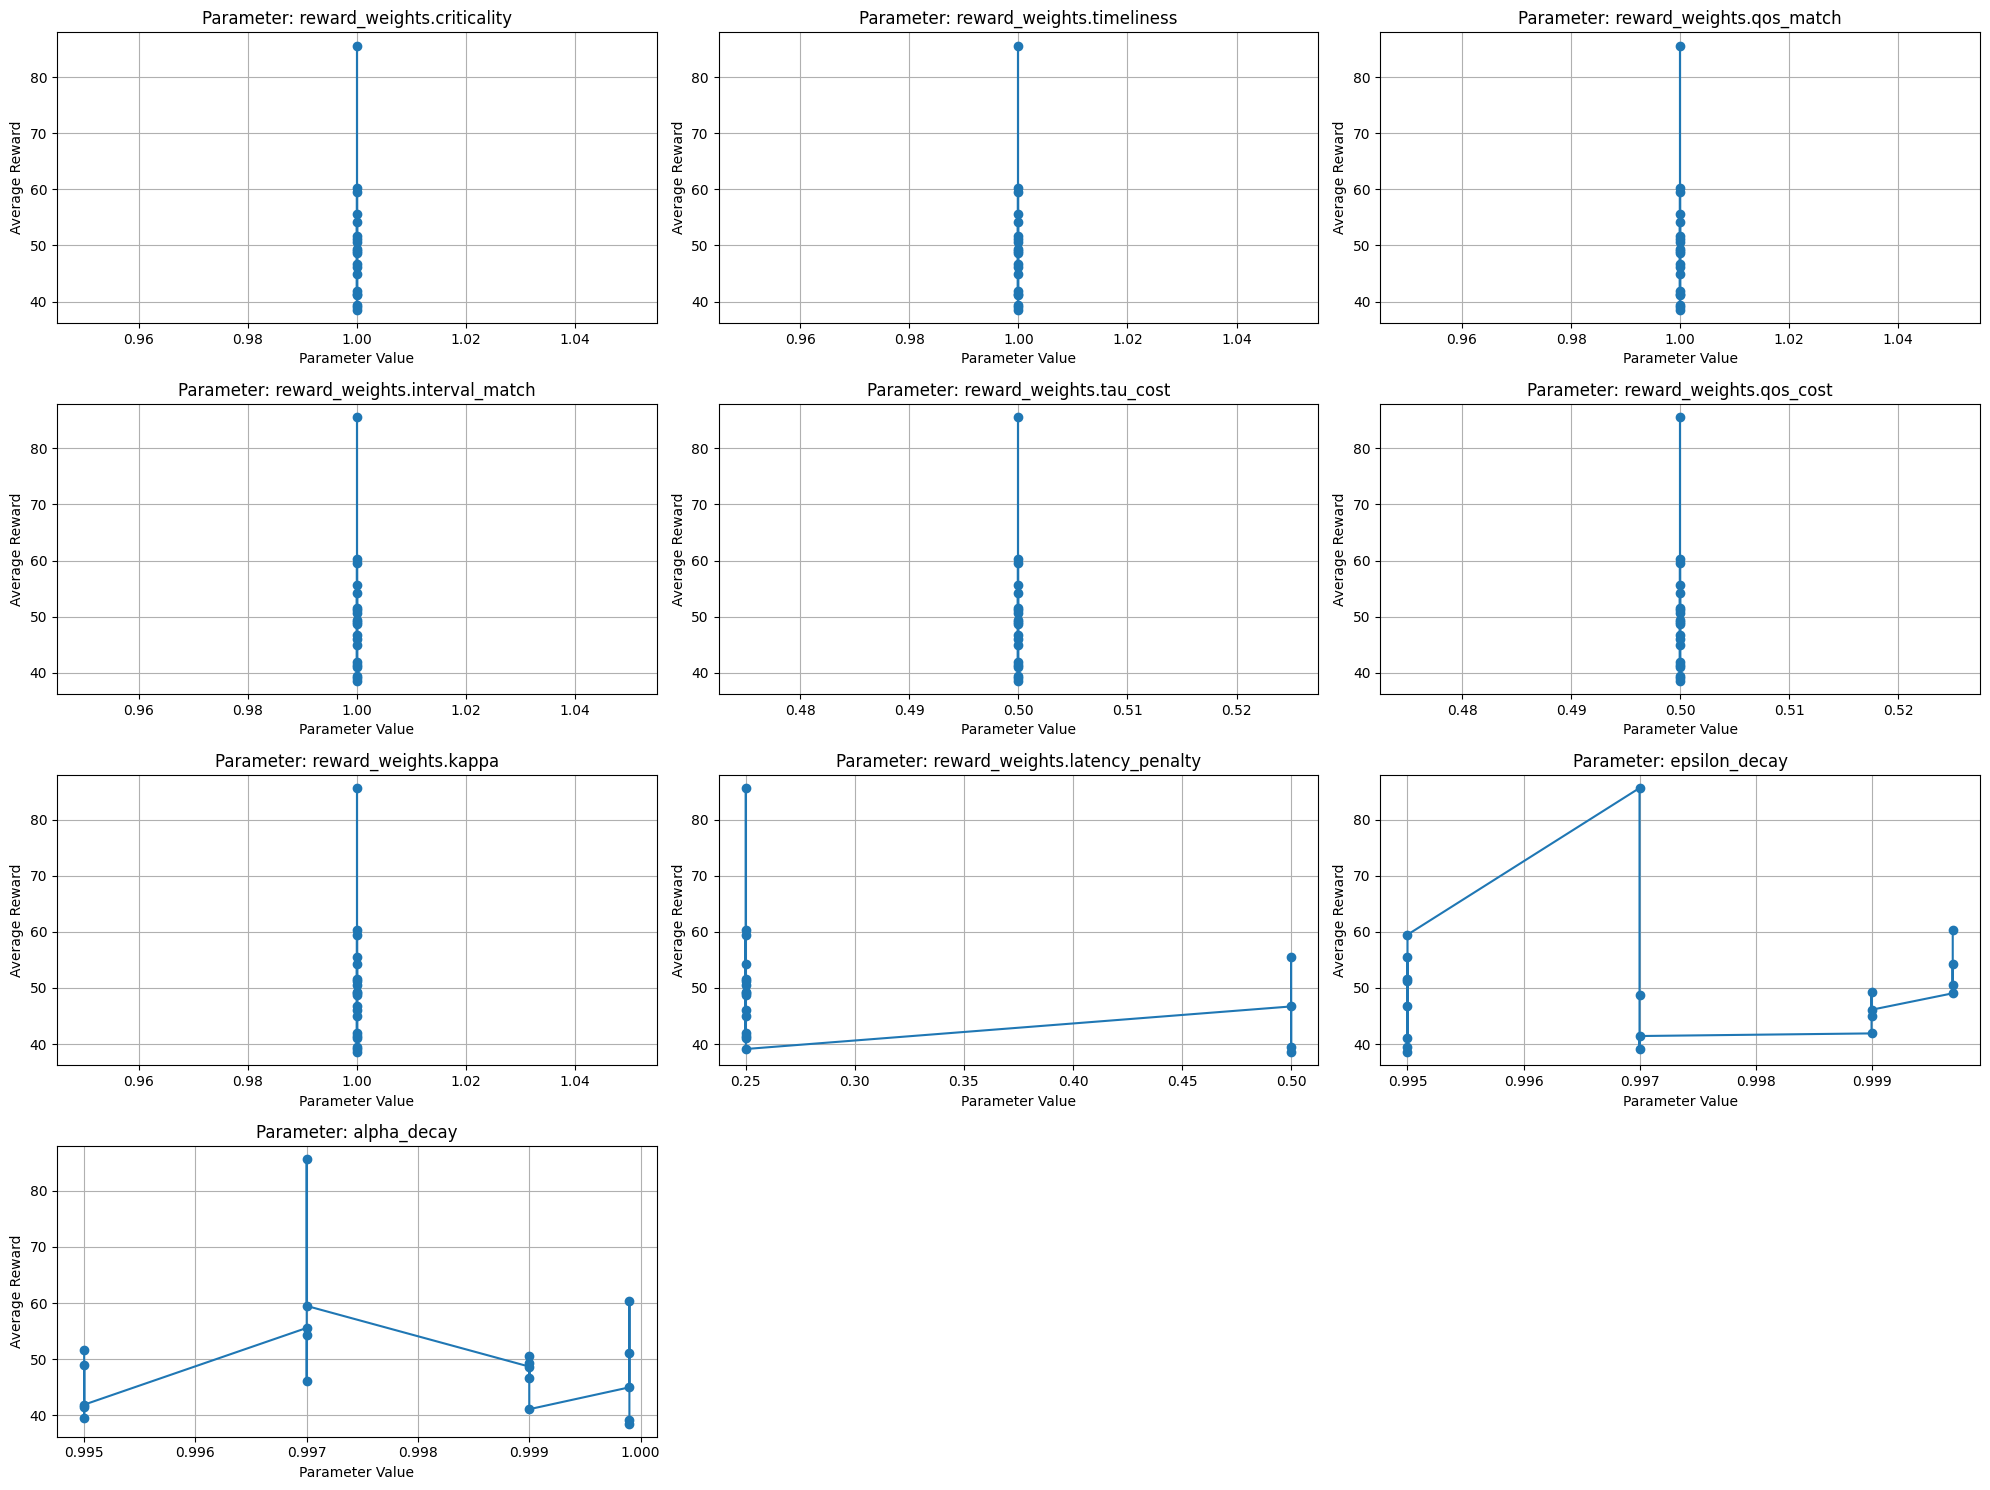

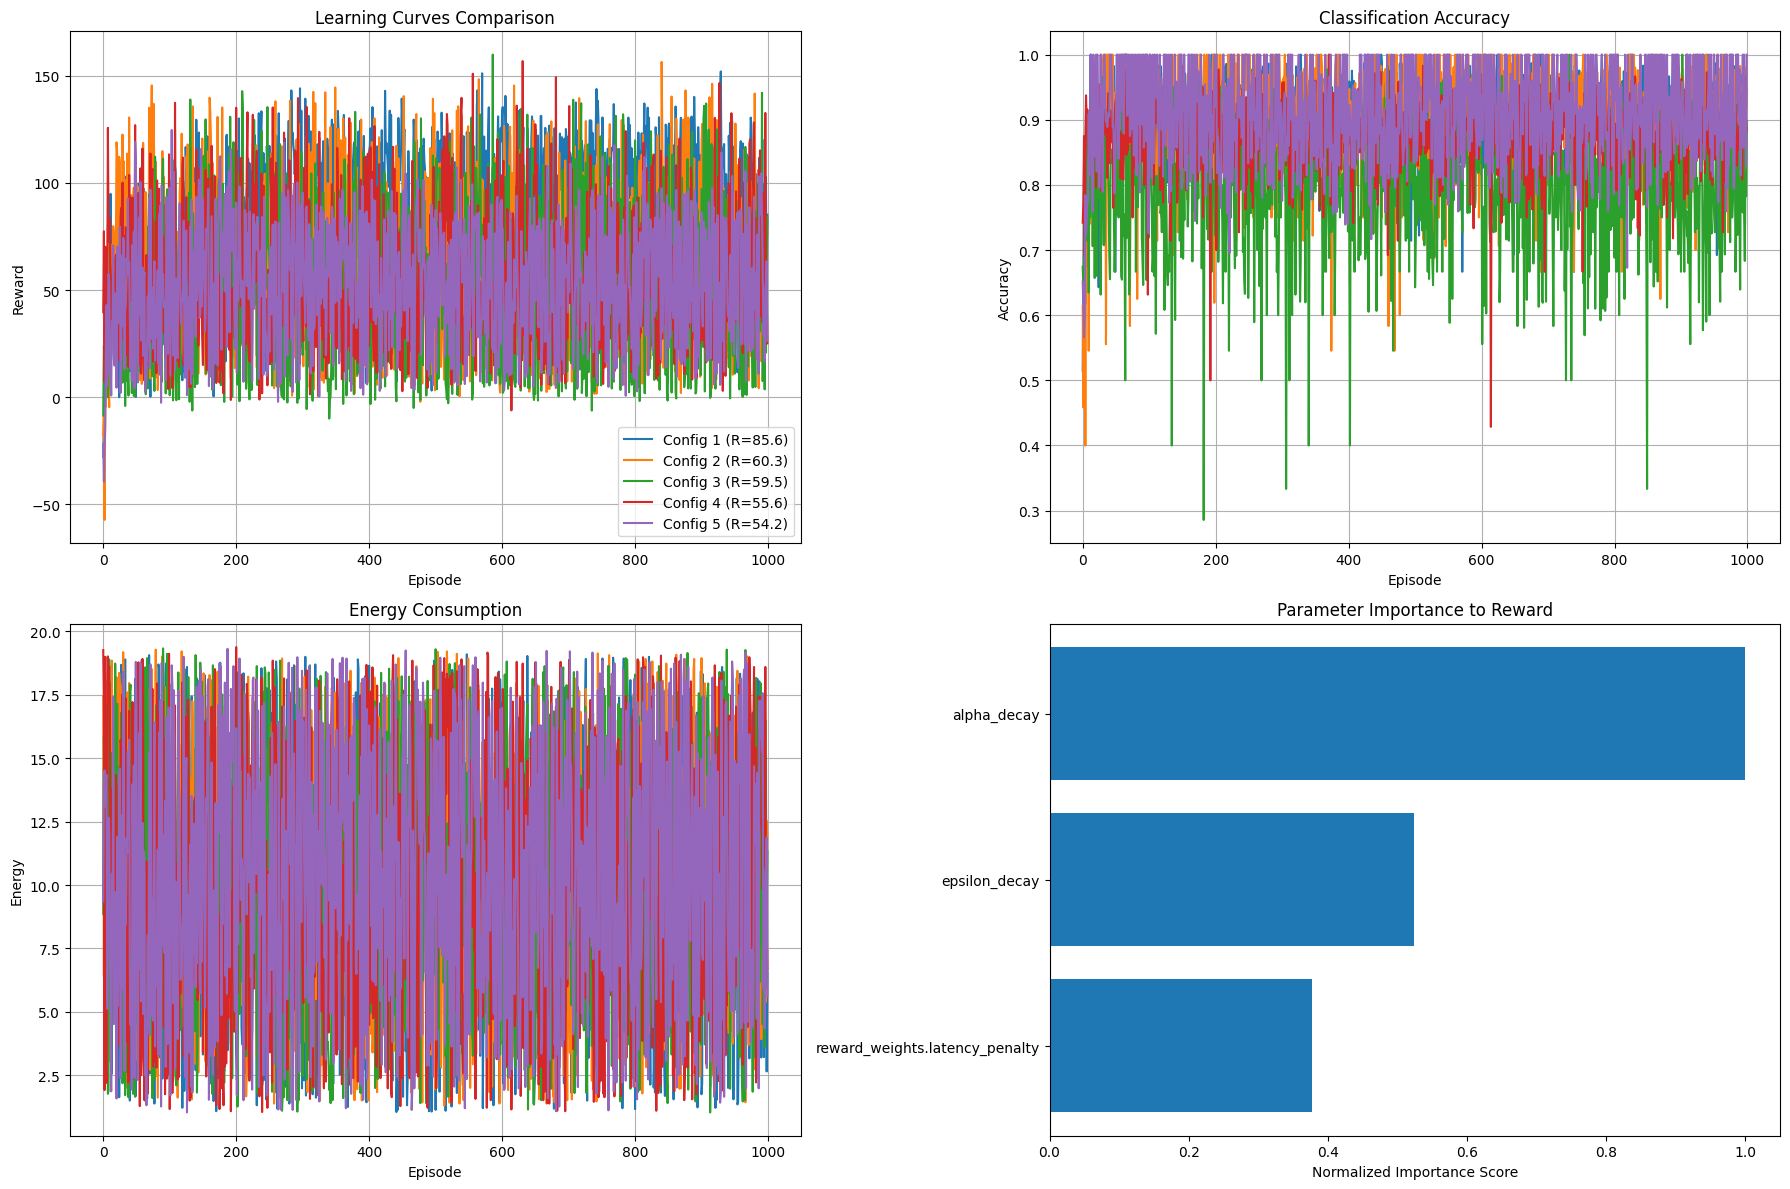


Best configuration found:
reward_weights.criticality: 1.0
reward_weights.timeliness: 1.0
reward_weights.qos_match: 1.0
reward_weights.interval_match: 1.0
reward_weights.tau_cost: 0.5
reward_weights.qos_cost: 0.5
reward_weights.kappa: 1.0
reward_weights.latency_penalty: 0.25
epsilon_decay: 0.997
alpha_decay: 0.997

Training final agent with best configuration...
Starting Q-learning training for 3000 episodes...


  7%|▋         | 219/3000 [00:01<00:17, 161.05it/s]

Coverage sweep at episode 200 ...


 14%|█▍        | 420/3000 [00:02<00:15, 167.20it/s]

Coverage sweep at episode 400 ...


...

Coverage sweep at episode 2800 ...


100%|██████████| 3000/3000 [00:16<00:00, 179.11it/s]


Training completed!


C:\Users\iamro\AppData\Local\Temp\ipykernel_17552\3143310861.py:663: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(4, 3, 10)



Policy Analysis with Expected Ideal Actions:

State (Δ0, B=2, L=0, D=0):
  Best action: QoS=1, Interval=60s, Critical=1
  Q-value: 3.00
  Ideal QoS: 0, Ideal Interval: 5s
  Critical match: ✗
  Top 1: QoS=1✗, τ=60s✗, c=1 (Q=3.00)
  Top 2: QoS=0✓, τ=60s✗, c=0 (Q=1.23)
  Top 3: QoS=2✗, τ=60s✗, c=0 (Q=1.17)

State (Δ2, B=0, L=2, D=2):
  Best action: QoS=2, Interval=5s, Critical=1
  Q-value: 3.21
  Ideal QoS: 2, Ideal Interval: 5s
  Critical match: ✓
  Top 1: QoS=2✓, τ=5s✓, c=1 (Q=3.21)
  Top 2: QoS=2✓, τ=30s✗, c=1 (Q=1.58)
  Top 3: QoS=1✗, τ=5s✓, c=1 (Q=1.52)

State (Δ1, B=1, L=1, D=1):
  Best action: QoS=1, Interval=30s, Critical=1
  Q-value: 3.33
  Ideal QoS: 1, Ideal Interval: 5s
  Critical match: ✓
  Top 1: QoS=1✓, τ=30s✗, c=1 (Q=3.33)
  Top 2: QoS=0✗, τ=60s✗, c=1 (Q=1.87)
  Top 3: QoS=1✓, τ=5s✓, c=1 (Q=1.68)

State-Action Pair Coverage Summary:
  State-action pairs encountered: 1458 / 1458 (100.00%)
  Well-visited pairs (≥10 visits): 1458 / 1458
  Unique states visited: 81 / 81 (100.

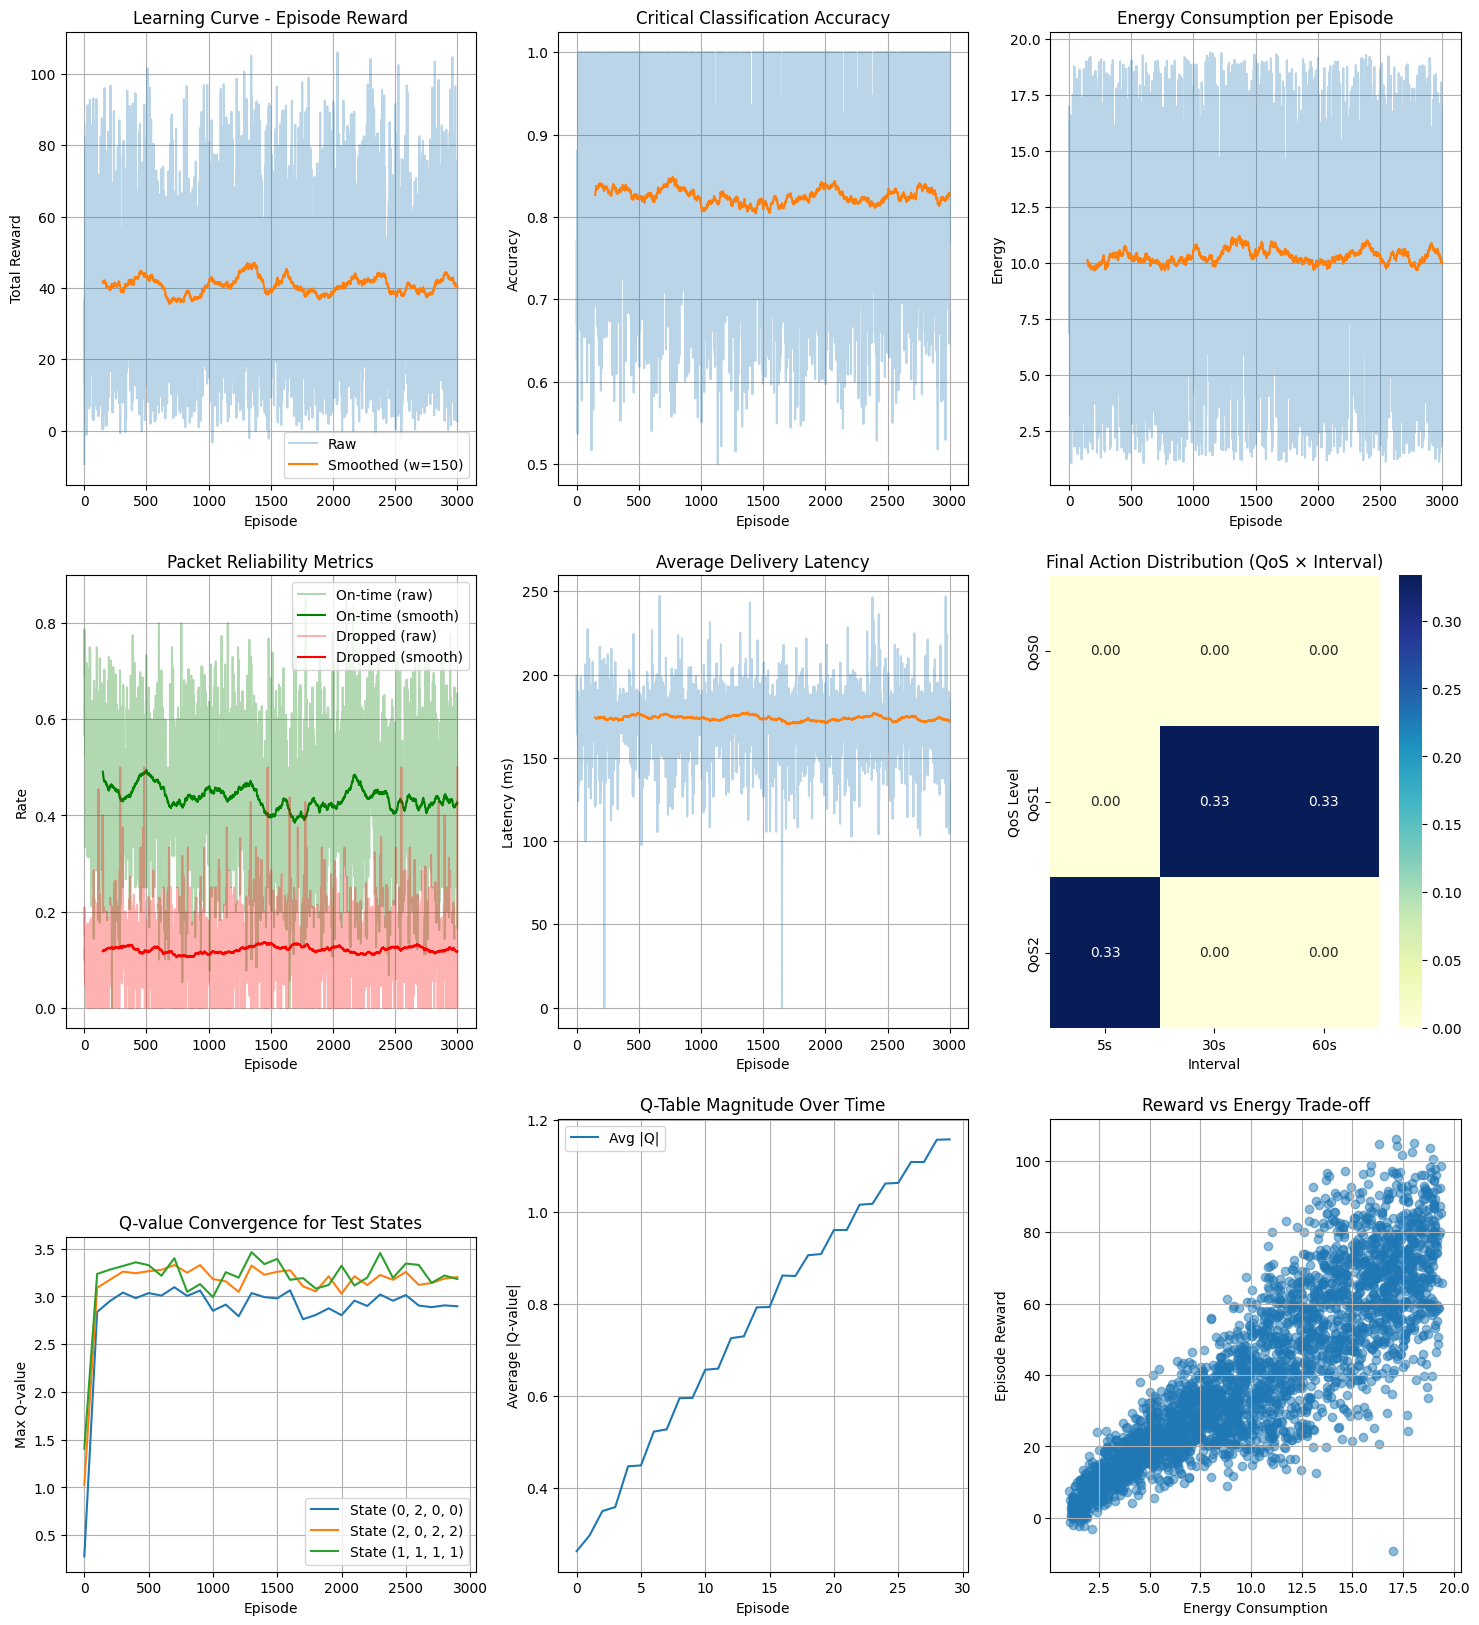

In [4]:
import itertools

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tqdm import tqdm


class RealisticEnvSimulator:
    def __init__(self):
        self.battery = 1.0
        self.window_size = 20
        self.delay_window = []
        self.loss_window = []
        self.delta_ema = None
        self.delta_alpha = 0.1
        self.delta_std = 1.0

    def update_ema(self, x):
        if self.delta_ema is None:
            self.delta_ema = x
        else:
            self.delta_ema = self.delta_alpha * x + \
                (1 - self.delta_alpha) * self.delta_ema
        return self.delta_ema

    def compute_delta(self, x):
        ema = self.update_ema(x)
        delta = abs(x - ema) / (self.delta_std + 1e-8)
        return delta

    def compute_loss_rate(self):
        if len(self.loss_window) < self.window_size:
            return 0.0
        return 1.0 - np.mean(self.loss_window[-self.window_size:])

    def compute_avg_delay(self):
        if len(self.delay_window) == 0:
            return 0
        return np.mean(self.delay_window[-self.window_size:])

    def discretize_state(self, delta, battery, loss, delay):
        """Convert continuous observations to discrete levels"""
        # Delta level
        if delta < 1:
            delta_lvl = 0   # Small
        elif delta < 3:
            delta_lvl = 1  # Medium
        else:
            delta_lvl = 2   # Large

        # Battery level
        if battery < 0.3:
            battery_lvl = 0   # Low
        elif battery < 0.7:
            battery_lvl = 1  # Medium
        else:
            battery_lvl = 2   # High

        # Loss level
        if loss < 0.1:
            loss_lvl = 0    # Low
        elif loss < 0.3:
            loss_lvl = 1  # Medium
        else:
            loss_lvl = 2    # High

        # Delay level
        if delay < 100:
            delay_lvl = 0    # Low
        elif delay < 500:
            delay_lvl = 1  # Medium
        else:
            delay_lvl = 2    # High

        return delta_lvl, battery_lvl, loss_lvl, delay_lvl

    def simulate_environment(self, state, action):
        delta_lvl, battery_lvl, loss_lvl, delay_lvl = state
        qos, interval, critical = action

        # --- Generate raw input values ---
        sensor_value = np.random.uniform(10, 30)  # fake temp
        delta = self.compute_delta(sensor_value)

        # --- Energy usage ---
        qos_energy = 0.05 * qos
        interval_energy = 2.0 / interval
        energy_cost = qos_energy + interval_energy
        self.battery = max(0.0, self.battery - energy_cost * 0.05)

        # --- Delay simulation ---
        base_delay = np.random.normal(100 + 50 * (2 - qos), 20)
        delay = np.clip(base_delay + 1000 / interval, 0, 800)
        self.delay_window.append(delay)

        # --- Packet loss simulation ---
        loss_chance = 0.1 * (2 - qos) + 0.01 * delay / \
            100  # more delay = more loss
        is_delivered = np.random.rand() > loss_chance
        self.loss_window.append(int(is_delivered))

        # --- Status & latency ---
        packet_status = 'dropped'
        if is_delivered:
            packet_status = 'on_time' if delay < 300 else 'late'
        latency = delay if is_delivered else 1000

        # --- Discretization for next state ---
        next_delta_lvl = 0 if delta < 1 else (1 if delta < 3 else 2)
        next_battery_lvl = 0 if self.battery < 0.3 else (
            1 if self.battery < 0.7 else 2)
        loss_rate = self.compute_loss_rate()
        next_loss_lvl = 0 if loss_rate < 0.1 else (1 if loss_rate < 0.3 else 2)
        avg_delay = self.compute_avg_delay()
        next_delay_lvl = 0 if avg_delay < 100 else (
            1 if avg_delay < 500 else 2)

        new_state = (next_delta_lvl, next_battery_lvl,
                     next_loss_lvl, next_delay_lvl)

        # --- True criticality logic ---
        delta_risk = delta_lvl
        battery_risk = 2 - battery_lvl
        loss_risk = loss_lvl
        delay_risk = delay_lvl
        qos_risk = qos

        total_risk = delta_risk + battery_risk + loss_risk + delay_risk + qos_risk
        normalized_risk = total_risk / 5
        true_crit = 1 if normalized_risk >= 1 else 0

        return new_state, packet_status, true_crit, energy_cost, latency


class TabularQLearningBaseline:
    def __init__(self):
        # Environment integration
        self.env = RealisticEnvSimulator()

        # Action space definitions (must come first!)
        self.qos_levels = [0, 1, 2]
        self.intervals = [5, 30, 60]  # in seconds
        self.critical_flags = [0, 1]

        # Environment parameters
        self.state_dims = [3, 3, 3, 3]  # Δ, Battery, Loss, Delay levels
        self.num_states = np.prod(self.state_dims)
        self.action_dims = [3, 3, 2]  # QoS, Interval, Critical
        self.num_actions = np.prod(self.action_dims)

        # Q-table initialization with small random values
        self.q_table = np.random.uniform(
            low=-0.1, high=0.1, size=(self.num_states, self.num_actions))
        for state_idx in range(self.num_states):
            loss_lvl = (state_idx // 3) % 3
            delay_lvl = state_idx % 3
            if loss_lvl >= 1 or delay_lvl >= 1:
                for qos in [1, 2]:
                    for interval in [5, 30]:
                        action_idx = self.action_to_index(qos, interval, 1)
                        self.q_table[state_idx, action_idx] = 1.0

        # Adaptive hyperparameters
        self.alpha_start = 0.8
        self.alpha_min = 0.05
        self.alpha_decay = 0.9995
        self.gamma = 0.95
        self.epsilon_start = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.999
        self.current_step = 0
        self.temperature_start = 1.0
        self.temperature_end = 0.1

        # Enhanced reward parameters
        self.reward_weights = {
            'timeliness': 1.5,      # Priority for on-time delivery
            'criticality': 2.0,     # Stress correct criticality labeling
            'qos_match': 2.0,       # Reward matching ideal QoS
            'interval_match': 2.0,  # Reward matching ideal interval
            'tau_cost': 1.0,        # Interval cost weight
            'qos_cost': 1.0,        # QoS cost weight
            'kappa': 2.0,           # Battery sensitivity
            'latency_penalty': 0.5  # Additional latency penalty
        }

        # Enhanced metrics tracking
        self.metrics = {
            'episode_rewards': [],
            'classification_accuracy': [],
            'energy_consumption': [],
            'on_time_rate': [],
            'drop_rate': [],
            'avg_latency': [],
            'action_distribution': defaultdict(list),
            'convergence_data': [],
            'q_values': [],
            'alpha_values': [],
            'epsilon_values': [],
            'criticality': []
        }

    def state_to_index(self, delta_lvl, battery_lvl, loss_lvl, delay_lvl):
        return (delta_lvl * 27 + battery_lvl * 9 +
                loss_lvl * 3 + delay_lvl)

    def action_to_index(self, qos, interval, critical):
        interval_idx = self.intervals.index(interval)
        return qos * 6 + interval_idx * 2 + critical

    def index_to_action(self, action_idx):
        qos = action_idx // 6
        remainder = action_idx % 6
        interval_idx = remainder // 2
        critical = remainder % 2
        return qos, self.intervals[interval_idx], critical

    def calculate_reward(self, state, action, packet_status, true_crit, latency):
        delta_lvl, battery_lvl, loss_lvl, delay_lvl = state
        qos, interval, critical = action

        # 1. Timeliness Reward (R_rel)
        if packet_status == 'on_time':
            R_rel = 1.0
        elif packet_status == 'late':
            R_rel = 0.5
        else:  # dropped
            R_rel = -1.0

        # 2. Criticality Reward (R_crit)
        R_crit = 1.0 if critical == true_crit else -1.0

        # 3. QoS-Match Reward (R_qos)
        ideal_qos = 2 if (loss_lvl >= 2 or delay_lvl >= 2) else \
            1 if (loss_lvl >= 1 or delay_lvl >= 1) else 0
        R_qos = 1.0 if qos == ideal_qos else -1.0

        # 4. Interval-Match Reward (R_int)
        ideal_interval = 5 if delta_lvl == 2 else \
            30 if delta_lvl == 1 else 60
        R_int = 1.0 if interval == ideal_interval else -1.0

        # Energy Penalty Calculation
        # Continuous battery representation [0.3, 1.1]
        battery = 0.3 + battery_lvl * 0.4

        # Battery factor (linear)
        f_Bt = 1 + self.reward_weights['kappa'] * (1 - battery)

        # Normalized action costs
        C_qos = qos / 2  # QoS 0→0.0, 1→0.5, 2→1.0
        C_int = (60 - interval) / (60 - 5)  # 5s→1.0, 30s→0.5, 60s→0.0

        # Combined penalty
        penalty = f_Bt * (self.reward_weights['tau_cost'] * C_int +
                          self.reward_weights['qos_cost'] * C_qos)

        # Total reward with weighted components
        total_reward = (self.reward_weights['timeliness'] * R_rel +
                        self.reward_weights['criticality'] * R_crit +
                        self.reward_weights['qos_match'] * R_qos +
                        self.reward_weights['interval_match'] * R_int -
                        penalty)

        # Additional penalty for latency (independent of packet status)
        latency_penalty = self.reward_weights['latency_penalty'] * min(
            1, latency/800)
        total_reward -= latency_penalty

        return np.clip(total_reward, -5.0, 5.0)

    def _get_ideal_qos(self, state):
        
        delta_lvl, battery_lvl, loss_lvl, delay_lvl = state

        # Higher QoS when network conditions are bad OR delta is large
        if loss_lvl >= 2 or delay_lvl >= 2 or delta_lvl >= 2:
            return 2
        elif (loss_lvl >= 1 or delay_lvl >= 1) and battery_lvl >= 1:
            return 1
        else:
            return 0

    def _get_ideal_interval(self, state):
        """Dynamic interval considering delta and battery"""
        delta_lvl, battery_lvl, _, _ = state

        # More frequent updates when delta is high OR battery is good
        if delta_lvl == 2 or battery_lvl >= 1:
            return 5
        elif delta_lvl == 1:
            return 30
        else:
            return 60

    def select_action(self, state_idx, training=True):
        """Improved exploration with Boltzmann and epsilon decay"""
        """ if training:
            self.epsilon = max(self.epsilon_min,
                               self.epsilon_start * (self.epsilon_decay ** self.current_step))

            if np.random.random() < self.epsilon:
                # Boltzmann exploration that considers all action dimensions
                temperature = max(0.1, 1.0 - (self.current_step / 10000))
                q_values = self.q_table[state_idx]
                exp_q = np.exp((q_values - np.max(q_values)) / temperature)
                prob = exp_q / np.sum(exp_q)
                return np.random.choice(self.num_actions, p=prob) 
            
            noise = np.random.randn(self.num_actions) * 0.01 * self.epsilon
            return np.argmax(self.q_table[state_idx] + noise)"""
        if training:
            self.epsilon = max(self.epsilon_min,
                               self.epsilon_start * (self.epsilon_decay ** self.current_step))

            if np.random.random() < self.epsilon:
                # Boltzmann exploration that considers all action dimensions
                temperature = max(0.1, 1.0 - (self.current_step / 10000))
                q_values = self.q_table[state_idx]
                exp_q = np.exp((q_values - np.max(q_values)) / temperature)
                prob = exp_q / np.sum(exp_q)
                return np.random.choice(self.num_actions, p=prob)

        # Exploitation with small noise that considers all dimensions
        noise = np.random.randn(self.num_actions) * 0.01 * self.epsilon
        return np.argmax(self.q_table[state_idx] + noise)

    def update_q_table(self, state_idx, action_idx, reward, next_state_idx):
        
        reward = np.clip(reward / 10.0, -0.5, 0.5)
        # Decaying learning rate
        self.alpha = max(self.alpha_min,
                         self.alpha_start * (self.alpha_decay ** self.current_step))

        current_q = self.q_table[state_idx, action_idx]
        max_next_q = np.max(self.q_table[next_state_idx])

        # Q-learning update with adaptive learning rate
        new_q = current_q + self.alpha * \
            (reward + self.gamma * max_next_q - current_q)
        self.q_table[state_idx, action_idx] = new_q

        # Track learning rate
        self.metrics['alpha_values'].append(self.alpha)
        self.current_step += 1

    def train(self, num_episodes=2000, eval_interval=100, sweep_interval=200):
        """Enhanced training loop with experience replay"""
        print(f"Starting Q-learning training for {num_episodes} episodes...")

        self.state_action_visits = defaultdict(int)
        self.state_visits = defaultdict(int)

        replay_buffer = []
        buffer_size = 1000
        batch_size = 32
        test_states = [
            (0, 2, 0, 0),
            (2, 0, 2, 2),
            (1, 1, 1, 1)
        ]
        test_state_indices = [self.state_to_index(*s) for s in test_states]
        for episode in tqdm(range(num_episodes)):
            episode_metrics = {
                'reward': 0,
                'correct_class': 0,
                'energy': 0,
                'packets_sent': 0,
                'on_time': 0,
                'dropped': 0,
                'latency': 0,
                'steps': 0
            }
            self.env = RealisticEnvSimulator()  
            delta = np.random.uniform(0, 4)
            battery = np.random.uniform(0.1, 1.0)  
            loss = np.random.uniform(0, 0.5)
            delay = np.random.uniform(0, 600)

            self.env.battery = battery

            state = self.env.discretize_state(delta, battery, loss, delay)
            state_idx = self.state_to_index(*state)

            done = False
            while not done and episode_metrics['steps'] < 100:
                action_idx = self.select_action(state_idx)
                action = self.index_to_action(action_idx)
                self.state_action_visits[(state_idx, action_idx)] += 1
                self.state_visits[state_idx] += 1
                # Simulate environment
                new_state, packet_status, true_crit, energy_cost, latency = \
                    self.env.simulate_environment(state, action)
                new_state_idx = self.state_to_index(*new_state)

                # Calculate reward
                reward = self.calculate_reward(
                    state, action, packet_status, true_crit, latency)

                # Store transition in replay buffer
                replay_buffer.append(
                    (state_idx, action_idx, reward, new_state_idx))
                if len(replay_buffer) > buffer_size:
                    replay_buffer.pop(0)

                # Update Q-table
                self.update_q_table(state_idx, action_idx,
                                    reward, new_state_idx)

                # Experience replay
                if len(replay_buffer) >= batch_size and episode % 5 == 0:
                    batch = np.random.choice(
                        len(replay_buffer), size=batch_size, replace=False)
                    for idx in batch:
                        s, a, r, s_next = replay_buffer[idx]
                        self.update_q_table(s, a, r, s_next)

                # Track metrics
                episode_metrics['reward'] += reward
                episode_metrics['correct_class'] += 1 if action[2] == true_crit else 0
                episode_metrics['energy'] += energy_cost
                episode_metrics['packets_sent'] += 1
                if packet_status == 'on_time':
                    episode_metrics['on_time'] += 1
                    episode_metrics['latency'] += latency
                elif packet_status == 'dropped':
                    episode_metrics['dropped'] += 1
                episode_metrics['steps'] += 1

                # Update state
                state = new_state
                state_idx = new_state_idx

                # Check termination
                if self.env.battery <= 0.05 or episode_metrics['steps'] >= 100:
                    done = True
            for test_state in test_states:
                for _ in range(5):  # each test state-action pair visited multiple times per episode
                    state_idx = self.state_to_index(*test_state)
                    action_idx = self.select_action(state_idx, training=True)
                    action = self.index_to_action(action_idx)

                    new_state, packet_status, true_crit, energy_cost, latency = \
                        self.env.simulate_environment(test_state, action)
                    new_state_idx = self.state_to_index(*new_state)

                    reward = self.calculate_reward(
                        test_state, action, packet_status, true_crit, latency)
                    self.update_q_table(
                        state_idx, action_idx, reward, new_state_idx)

                    self.state_action_visits[(state_idx, action_idx)] += 1
                    self.state_visits[state_idx] += 1
            
            self.metrics['episode_rewards'].append(episode_metrics['reward'])
            self.metrics['classification_accuracy'].append(
                episode_metrics['correct_class'] / episode_metrics['steps'] if episode_metrics['steps'] > 0 else 0)
            self.metrics['energy_consumption'].append(
                episode_metrics['energy'])
            self.metrics['on_time_rate'].append(
                episode_metrics['on_time'] / episode_metrics['packets_sent'] if episode_metrics['packets_sent'] > 0 else 0)
            self.metrics['drop_rate'].append(
                episode_metrics['dropped'] / episode_metrics['packets_sent'] if episode_metrics['packets_sent'] > 0 else 0)
            self.metrics['avg_latency'].append(
                episode_metrics['latency'] / episode_metrics['on_time'] if episode_metrics['on_time'] > 0 else 0)
            self.metrics['epsilon_values'].append(self.epsilon)

            if episode > 0 and episode % sweep_interval == 0:
                print(f"Coverage sweep at episode {episode} ...")
                for delta_lvl in range(3):
                    for battery_lvl in range(3):
                        for loss_lvl in range(3):
                            for delay_lvl in range(3):
                                state = (delta_lvl, battery_lvl,
                                         loss_lvl, delay_lvl)
                                state_idx = self.state_to_index(*state)
                                for qos in range(3):
                                    for interval in [5, 30, 60]:
                                        for critical in [0, 1]:
                                            action_idx = self.action_to_index(
                                                qos, interval, critical)
                                            self.state_action_visits[(
                                                state_idx, action_idx)] += 1
                                            self.state_visits[state_idx] += 1

                                            self.env = RealisticEnvSimulator()
                                            self.env.battery = 0.5
                                            new_state, packet_status, true_crit, energy_cost, latency = \
                                                self.env.simulate_environment(
                                                    state, (qos, interval, critical))
                                            new_state_idx = self.state_to_index(
                                                *new_state)
                                            reward = self.calculate_reward(
                                                state, (qos, interval, critical), packet_status, true_crit, latency)
                                            self.update_q_table(
                                                state_idx, action_idx, reward, new_state_idx)
            if episode % eval_interval == 0:
                self._evaluate_policy(episode)
                # Q-value tracking
                self.metrics['q_values'].append(np.mean(np.abs(self.q_table)))

        print("Training completed!")
        return self.metrics

    def _evaluate_policy(self, episode):
        
        test_states = [
            (0, 2, 0, 0),  
            (2, 0, 2, 2),  
            (1, 1, 1, 1)   
        ]

        action_counts = np.zeros((3, 3))  
        crit_counts = np.zeros(2)  
        state_q_values = {}
        for state in test_states:
            state_idx = self.state_to_index(*state)
            action_idx = self.select_action(
                state_idx, training=False)  # Greedy
            qos, interval, critical = self.index_to_action(action_idx)

            interval_idx = self.intervals.index(interval)
            action_counts[qos, interval_idx] += 1
            crit_counts[critical] += 1
            state_q_values[state] = np.max(self.q_table[state_idx])
        # Store for plotting
        self.metrics['convergence_data'].append({
            'episode': episode,
            'action_dist': action_counts / len(test_states),
            'crit_dist': crit_counts / len(test_states),
            'avg_q': np.mean(np.abs(self.q_table)),
            'state_q_values': state_q_values
        })

    def plot_metrics(self):
        """Plot all requested metrics"""
        plt.figure(figsize=(18, 20))

        # Determine smoothing window
        window = max(1, len(self.metrics['episode_rewards']) // 20)

        # 1. Learning Curve - Average Reward
        plt.subplot(3, 3, 1)
        rewards = self.metrics['episode_rewards']
        if len(rewards) > 0:
            smooth_rewards = np.convolve(
                rewards, np.ones(window)/window, mode='valid')
            plt.plot(rewards, alpha=0.3, label='Raw')
            plt.plot(range(window-1, len(rewards)), smooth_rewards,
                     label=f'Smoothed (w={window})')
        plt.xlabel('Episode')
        plt.ylabel('Total Reward')
        plt.title('Learning Curve - Episode Reward')
        plt.legend()
        plt.grid(True)

        # 2. Classification Accuracy
        plt.subplot(3, 3, 2)
        accuracy = self.metrics['classification_accuracy']
        if len(accuracy) > 0:
            smooth_acc = np.convolve(
                accuracy, np.ones(window)/window, mode='valid')
            plt.plot(accuracy, alpha=0.3)
            plt.plot(range(window-1, len(accuracy)), smooth_acc)
        plt.xlabel('Episode')
        plt.ylabel('Accuracy')
        plt.title('Critical Classification Accuracy')
        plt.grid(True)

        # 3. Energy Consumption
        plt.subplot(3, 3, 3)
        energy = self.metrics['energy_consumption']
        if len(energy) > 0:
            smooth_energy = np.convolve(
                energy, np.ones(window)/window, mode='valid')
            plt.plot(energy, alpha=0.3)
            plt.plot(range(window-1, len(energy)), smooth_energy)
        plt.xlabel('Episode')
        plt.ylabel('Energy')
        plt.title('Energy Consumption per Episode')
        plt.grid(True)

        # 4. Reliability Metrics
        plt.subplot(3, 3, 4)
        on_time = self.metrics['on_time_rate']
        dropped = self.metrics['drop_rate']
        if len(on_time) > 0 and len(dropped) > 0:
            smooth_ot = np.convolve(
                on_time, np.ones(window)/window, mode='valid')
            smooth_dr = np.convolve(
                dropped, np.ones(window)/window, mode='valid')
            plt.plot(on_time, alpha=0.3, color='green', label='On-time (raw)')
            plt.plot(range(window-1, len(on_time)), smooth_ot,
                     color='green', label='On-time (smooth)')
            plt.plot(dropped, alpha=0.3, color='red', label='Dropped (raw)')
            plt.plot(range(window-1, len(dropped)), smooth_dr,
                     color='red', label='Dropped (smooth)')
        plt.xlabel('Episode')
        plt.ylabel('Rate')
        plt.title('Packet Reliability Metrics')
        plt.legend()
        plt.grid(True)

        # 5. Average Latency
        plt.subplot(3, 3, 5)
        latency = self.metrics['avg_latency']
        if len(latency) > 0:
            smooth_lat = np.convolve(
                latency, np.ones(window)/window, mode='valid')
            plt.plot(latency, alpha=0.3)
            plt.plot(range(window-1, len(latency)), smooth_lat)
        plt.xlabel('Episode')
        plt.ylabel('Latency (ms)')
        plt.title('Average Delivery Latency')
        plt.grid(True)

        # 6. Action Distribution Heatmap (final)
        plt.subplot(3, 3, 6)
        if self.metrics['convergence_data']:
            final_actions = self.metrics['convergence_data'][-1]['action_dist']
            sns.heatmap(final_actions, annot=True, fmt='.2f',
                        xticklabels=['5s', '30s', '60s'],
                        yticklabels=['QoS0', 'QoS1', 'QoS2'],
                        cmap='YlGnBu')
            plt.title('Final Action Distribution (QoS × Interval)')
            plt.xlabel('Interval')
            plt.ylabel('QoS Level')

        # 7. Critical Flag Rate Over Time
        plt.subplot(3, 3, 7)
        if self.metrics['convergence_data']:
            crit_data = [x['crit_dist'][1]
                         for x in self.metrics['convergence_data']]
            episodes = [x['episode'] for x in self.metrics['convergence_data']]
            plt.plot(episodes, crit_data)
        plt.xlabel('Episode')
        plt.ylabel('Critical Flag Rate')
        plt.title('Critical Transmission Rate Over Time')
        plt.grid(True)

        # 8. Q-Value Magnitude
        plt.subplot(3, 3, 8)
        if len(self.metrics['q_values']) > 0:
            plt.plot(self.metrics['q_values'], label='Avg |Q|')
            plt.legend()
        plt.xlabel('Episode')
        plt.ylabel('Average |Q-value|')
        plt.title('Q-Table Magnitude Over Time')
        plt.grid(True)

        # 9. Reward vs Energy Consumption
        plt.subplot(3, 3, 9)
        if len(self.metrics['energy_consumption']) > 0 and len(self.metrics['episode_rewards']) > 0:
            plt.scatter(self.metrics['energy_consumption'],
                        self.metrics['episode_rewards'], alpha=0.5)
        plt.xlabel('Energy Consumption')
        plt.ylabel('Episode Reward')
        plt.title('Reward vs Energy Trade-off')
        plt.grid(True)
        # 10. Q-value Convergence for Test States
        plt.subplot(4, 3, 10)
        test_states = [
            (0, 2, 0, 0),  # Optimal conditions
            (2, 0, 2, 2),  # Worst conditions
            (1, 1, 1, 1)   # Mixed conditions
        ]

        for state in test_states:
            q_values = [data['state_q_values'][state]
                        for data in self.metrics['convergence_data']]
            episodes = [data['episode']
                        for data in self.metrics['convergence_data']]
            plt.plot(episodes, q_values, label=f'State {state}')

        plt.xlabel('Episode')
        plt.ylabel('Max Q-value')
        plt.title('Q-value Convergence for Test States')
        plt.legend()
        plt.grid(True)

    def analyze_policy(self):
        """Analyze the learned policy with expected ideal actions"""
        print("\nPolicy Analysis with Expected Ideal Actions:")

        test_states = [
            (0, 2, 0, 0),  # Small Δ, High battery, Low loss/delay
            (2, 0, 2, 2),  # Large Δ, Low battery, High loss/delay
            (1, 1, 1, 1)   # Medium everything
        ]

        for state in test_states:
            state_idx = self.state_to_index(*state)
            best_action_idx = np.argmax(self.q_table[state_idx])
            qos, interval, critical = self.index_to_action(best_action_idx)

            # Calculate expected ideal actions
            ideal_qos = self._get_ideal_qos(state)
            ideal_interval = self._get_ideal_interval(state)
            true_crit = 1 if (sum(state) + qos) / \
                5 >= 1 else 0  # Simplified criticality

            print(
                f"\nState (Δ{state[0]}, B={state[1]}, L={state[2]}, D={state[3]}):")
            print(
                f"  Best action: QoS={qos}, Interval={interval}s, Critical={critical}")
            print(f"  Q-value: {self.q_table[state_idx, best_action_idx]:.2f}")
            print(
                f"  Ideal QoS: {ideal_qos}, Ideal Interval: {ideal_interval}s")
            print(f"  Critical match: {'✓' if critical == true_crit else '✗'}")

            # Show top 3 actions
            top_actions = np.argsort(self.q_table[state_idx])[-3:][::-1]
            for i, act_idx in enumerate(top_actions):
                q, tau, c = self.index_to_action(act_idx)
                match_qos = "✓" if q == ideal_qos else "✗"
                match_int = "✓" if tau == ideal_interval else "✗"
                print(
                    f"  Top {i+1}: QoS={q}{match_qos}, τ={tau}s{match_int}, c={c} (Q={self.q_table[state_idx, act_idx]:.2f})")

    def summarize_coverage(self, well_visited_threshold=10, print_least_n=5):

        total_pairs = self.num_states * self.num_actions
        total_pairs_encountered = len(self.state_action_visits)
        well_visited_pairs = sum(
            1 for v in self.state_action_visits.values() if v >= well_visited_threshold)
        unique_states_visited = len(self.state_visits)
        coverage_percent = 100 * total_pairs_encountered / total_pairs
        state_coverage = 100 * unique_states_visited / self.num_states

        # Distribution of visits for all pairs
        visit_counts = list(self.state_action_visits.values())
        most_visited = max(visit_counts) if visit_counts else 0
        least_visited = min(visit_counts) if visit_counts else 0

        print("\nState-Action Pair Coverage Summary:")
        print(
            f"  State-action pairs encountered: {total_pairs_encountered} / {total_pairs} ({coverage_percent:.2f}%)")
        print(
            f"  Well-visited pairs (≥{well_visited_threshold} visits): {well_visited_pairs} / {total_pairs}")
        print(
            f"  Unique states visited: {unique_states_visited} / {self.num_states} ({state_coverage:.2f}%)")
        print(f"  Most visited state-action pair: {most_visited} times")
        print(f"  Least visited state-action pair: {least_visited} times")
        print(
            f"  Median visits per encountered pair: {np.median(visit_counts) if visit_counts else 0:.1f}")
        print(
            f"  Average visits per encountered pair: {np.mean(visit_counts) if visit_counts else 0:.1f}")

        # Optionally: Show the N least visited state-action pairs for debugging
        if print_least_n > 0 and visit_counts:
            print(
                f"\n{print_least_n} Least-visited (state, action) pairs and counts:")
            sorted_visits = sorted(
                self.state_action_visits.items(), key=lambda x: x[1])
            for ((s_idx, a_idx), count) in sorted_visits[:print_least_n]:
                state = (s_idx // 27, (s_idx % 27) //
                         9, (s_idx % 9) // 3, s_idx % 3)
                qos = a_idx // 6
                interval = [5, 30, 60][(a_idx % 6) // 2]
                critical = a_idx % 2
                print(
                    f"  State: {state}, Action: (QoS={qos}, Interval={interval}, Crit={critical}) --> {count} visits")


class ParameterSweeper:
    def __init__(self, base_agent_class):
        self.base_agent_class = base_agent_class
        self.results = []
        
    def define_parameter_ranges(self):
        return {
            'reward_weights.criticality': [1.0, 1.5, 2.0, 2.5, 3.0],
            'reward_weights.timeliness': [1.0, 1.25, 1.5, 1.75, 2.0],
            'reward_weights.qos_match': [1.0, 1.5, 2.0, 2.5, 3.0],
            'reward_weights.interval_match': [1.0, 1.5, 2.0, 2.5, 3.0],
            'reward_weights.tau_cost': [0.5, 1.0, 1.5, 2.0],
            'reward_weights.qos_cost': [0.5, 1.0, 1.5, 2.0],
            'reward_weights.kappa': [1.0, 1.5, 2.0, 2.5, 3.0],
            'reward_weights.latency_penalty': [0.25, 0.5, 0.75, 1.0],
            'epsilon_decay': [0.995, 0.997, 0.999, 0.9997],
            'alpha_decay': [0.995, 0.997, 0.999, 0.9999]
        }
    
    def generate_configs(self):
        param_ranges = self.define_parameter_ranges()
        param_names = param_ranges.keys()
        value_combinations = itertools.product(*param_ranges.values())
        
        configs = []
        for values in value_combinations:
            config = dict(zip(param_names, values))
            configs.append(config)
        return configs
    
    def run_sweep(self, num_episodes=1000, max_configs=50):
        configs = self.generate_configs()
        if len(configs) > max_configs:
            configs = configs[:max_configs]  # Limit for practical testing
            
        for config in tqdm(configs, desc="Parameter Sweep"):
            agent = self.create_configured_agent(config)
            metrics = agent.train(num_episodes=num_episodes)
            self.store_results(config, metrics)
    
    
    def create_configured_agent(self, config):
        agent = self.base_agent_class()
        
        for param_path, value in config.items():
            parts = param_path.split('.')
            obj = agent
            if parts[0] == 'reward_weights':
                if hasattr(obj, 'reward_weights'):
                    obj.reward_weights[parts[1]] = value
                continue
            for part in parts[:-1]:
                obj = getattr(obj, part)
            setattr(obj, parts[-1], value)
            
        return agent
    
    def store_results(self, config, metrics):
        # Store final performance metrics
        final_reward = np.mean(metrics['episode_rewards'][-100:])  # Last 100 episodes
        final_accuracy = np.mean(metrics['classification_accuracy'][-100:])
        final_energy = np.mean(metrics['energy_consumption'][-100:])
        
        self.results.append({
            'config': config,
            'final_reward': final_reward,
            'final_accuracy': final_accuracy,
            'final_energy': final_energy,
            'metrics': metrics  # Store full metrics for detailed analysis
        })
    
    def plot_sweep_results(self):
        """Plot parameter performance comparisons"""
        plt.figure(figsize=(20, 15))
        
        param_ranges = self.define_parameter_ranges()
        
        for i, param in enumerate(param_ranges.keys(), 1):
            plt.subplot(4, 3, i)
            
            # Group results by parameter value
            param_values = []
            rewards = []
            
            for result in self.results:
                value = result['config'].get(param, None)
                if value is not None:
                    param_values.append(value)
                    rewards.append(result['final_reward'])
            
            if param_values:
                # Sort by parameter value for clean plotting
                sort_idx = np.argsort(param_values)
                param_values = np.array(param_values)[sort_idx]
                rewards = np.array(rewards)[sort_idx]
                
                plt.plot(param_values, rewards, 'o-')
                plt.title(f"Parameter: {param}")
                plt.xlabel("Parameter Value")
                plt.ylabel("Average Reward")
                plt.grid(True)
        
        plt.tight_layout()
        plt.show()
    
    def plot_metric_comparisons(self):
        """Compare metrics across different parameter settings"""
        plt.figure(figsize=(18, 12))
        
        # Select top 5 configurations by final reward
        top_configs = sorted(self.results, key=lambda x: x['final_reward'], reverse=True)[:5]
        
        # 1. Learning Curves Comparison
        plt.subplot(2, 2, 1)
        for i, result in enumerate(top_configs):
            rewards = result['metrics']['episode_rewards']
            label = f"Config {i+1} (R={result['final_reward']:.1f})"
            plt.plot(rewards, label=label)
        plt.xlabel('Episode')
        plt.ylabel('Reward')
        plt.title('Learning Curves Comparison')
        plt.legend()
        plt.grid(True)
        
        # 2. Accuracy Comparison
        plt.subplot(2, 2, 2)
        for i, result in enumerate(top_configs):
            acc = result['metrics']['classification_accuracy']
            plt.plot(acc, label=f"Config {i+1}")
        plt.xlabel('Episode')
        plt.ylabel('Accuracy')
        plt.title('Classification Accuracy')
        plt.grid(True)
        
        # 3. Energy Comparison
        plt.subplot(2, 2, 3)
        for i, result in enumerate(top_configs):
            energy = result['metrics']['energy_consumption']
            plt.plot(energy, label=f"Config {i+1}")
        plt.xlabel('Episode')
        plt.ylabel('Energy')
        plt.title('Energy Consumption')
        plt.grid(True)
        
        # 4. Parameter Importance
        plt.subplot(2, 2, 4)
        param_importance = self.analyze_parameter_importance()
        params = list(param_importance.keys())
        importance = list(param_importance.values())
        plt.barh(params, importance)
        plt.title('Parameter Importance to Reward')
        plt.xlabel('Normalized Importance Score')
        plt.tight_layout()
        
        plt.show()
    
    def analyze_parameter_importance(self):
        """Calculate how much each parameter affects the final reward"""
        param_importance = {}
        param_ranges = self.define_parameter_ranges()
        
        for param in param_ranges.keys():
            # Group results by parameter value
            param_values = []
            rewards = []
            
            for result in self.results:
                value = result['config'].get(param, None)
                if value is not None:
                    param_values.append(value)
                    rewards.append(result['final_reward'])
            
            if param_values:
                # Calculate reward range for this parameter
                unique_values = np.unique(param_values)
                value_rewards = []
                
                for v in unique_values:
                    mask = np.array(param_values) == v
                    value_rewards.append(np.mean(np.array(rewards)[mask]))
                
                if len(value_rewards) > 1:
                    importance = np.max(value_rewards) - np.min(value_rewards)
                    param_importance[param] = importance
        
        # Normalize importance scores
        max_importance = max(param_importance.values()) if param_importance else 1
        for param in param_importance:
            param_importance[param] /= max_importance
            
        return dict(sorted(param_importance.items(), key=lambda item: item[1]))

# Modified main execution
if __name__ == "__main__":
    # Run parameter sweep
    sweeper = ParameterSweeper(TabularQLearningBaseline)
    sweeper.run_sweep(num_episodes=1000, max_configs=20)  # Reduced episodes for faster sweep
    
    # Plot results
    sweeper.plot_sweep_results()
    sweeper.plot_metric_comparisons()
    
    # Train final agent with best configuration
    best_config = max(sweeper.results, key=lambda x: x['final_reward'])['config']
    print("\nBest configuration found:")
    for k, v in best_config.items():
        print(f"{k}: {v}")
    
    print("\nTraining final agent with best configuration...")
    final_agent = sweeper.create_configured_agent(best_config)
    final_metrics = final_agent.train(num_episodes=3000)
    final_agent.plot_metrics()
    final_agent.analyze_policy()
    final_agent.summarize_coverage()

| Function (class)            | Parameter name in code                               | Practical sweep range               |
| --------------------------- | ---------------------------------------------------- | ----------------------------------- |
| `calculate_reward()`        | `self.reward_weights['criticality']`                 | **1.0 – 3.0** (step 0.5)            |
| same                        | `self.reward_weights['timeliness']`                  | **1.0 – 2.0**                       |
| same                        | `self.reward_weights['qos_match']`, `interval_match` | **1.0 – 3.0** (coupled or separate) |
| same                        | `self.reward_weights['tau_cost']`, `qos_cost`        | **0.5 – 2.0**                       |
| same                        | `self.reward_weights['kappa']`                       | **1.0 – 3.0**                       |
| same                        | `self.reward_weights['latency_penalty']`             | **0.25 – 1.0**                      |
| `select_action()` (tabular) | `epsilon_decay`                                      | **0.995 – 0.9997**                  |
| same (PPO)                  | `entropy_coef`                                       | **0.001 – 0.05**                    |
| `update_q_table()`          | `alpha_decay`                                        | **0.995 – 0.9999**                  |
| `update()` (PPO)            | `clip_param`                                         | **0.1 – 0.3**                       |
| same                        | `value_loss_coef`                                    | **0.3 – 1.0**                       |
